# Adaptive RAG (Retrieval-Augmented Generation)

Adaptive RAG is an advanced evolution of the standard RAG framework.

While standard RAG blindly retrieves documents for every query, **Adaptive RAG adds intelligence** to decide:

- if retrieval is needed  
- when to retrieve  
- how to retrieve  

based on the complexity of the user’s request.

Think of it as moving from a fixed assembly line to a smart workshop that selects different tools for different jobs.

---

## 🔁 How Adaptive RAG Works: The Workflow

The adaptive behavior comes from a **Query Classifier** (typically a small, fast LLM) that acts as a gatekeeper.

---

### Step 1: Query Analysis & Classification

The system sorts incoming queries into three categories:

#### ✅ Simple  
Answered directly from internal knowledge  
> Example: “What is the capital of France?”

#### 🔍 Moderate  
Needs a quick lookup from one reliable source  
> Example: “What was Apple’s stock price yesterday?”

#### 🧠 Complex  
Requires multi-source or multi-hop reasoning  
> Example: “Compare Tesla and Ford’s 2024 environmental policies and their impact on Q1 earnings.”

---

### Step 2: Strategy Selection

Based on classification, the system chooses:

- **No Retrieval**  
  Skip search to save time and cost

- **Single-Step Retrieval**  
  Fetch top results and generate answer

- **Multi-Step / Iterative Retrieval**  
  Break query into sub-questions and search repeatedly as needed

---

### Step 3: Self-Reflection & Grading

Many Adaptive RAG systems include self-correction loops:

- **Relevance Grader**  
  → Are documents actually useful?

- **Hallucination Grader**  
  → Is the answer grounded in facts?

If quality is poor, the system rewrites the query and retries.

---

## 📊 Adaptive RAG vs Standard RAG

| Feature | Standard RAG | Adaptive RAG |
|--------|------------|-------------|
| Logic | Static & Linear | Dynamic & Branching |
| Efficiency | Wastes resources | Conserves resources |
| Complexity Handling | Struggles with multi-hop | Excels at layered queries |
| Accuracy | Noisy retrieval | Uses graders |
| Latency | Always similar | Fast for simple, deeper for complex |

---

## 🎯 Why Adaptive RAG Matters

### 💰 Cost
Avoids unnecessary expensive retrieval calls

### 🎯 Accuracy
Self-reflection reduces hallucinations

### 📈 Scalability
Supports everything from FAQs to deep research

---

## 📌 Example Scenario

**User Query:**  
“Who won the Super Bowl last night and how does that compare to their 1990s record?”

### Standard RAG
Retrieves mixed documents at once → messy synthesis

### Adaptive RAG Flow

1. Detects complex query  
2. Searches for latest winner  
3. Searches historical stats  
4. Compares and synthesizes results  

---

## 🧬 RAG Intelligence Progression

| Feature | Standard RAG | Corrective RAG (CRAG) | Adaptive RAG |
|--------|-------------|----------------------|-------------|
| Workflow | Retrieve → Generate | Check → Fix → Generate | Classify → Route → Generate |
| Retrieval Policy | Always | Quality-checked | Optional |
| Backup Strategy | None | Web search | Strategy switching |
| Complexity | Low | Medium | High |
| Best For | Simple FAQs | High-accuracy systems | Advanced AI agents |

---

### ✅ Final Thought

- Standard RAG = baseline  
- Corrective RAG = quality control  
- Adaptive RAG = strategic intelligence layer  

Together, they form the future of reliable AI systems.


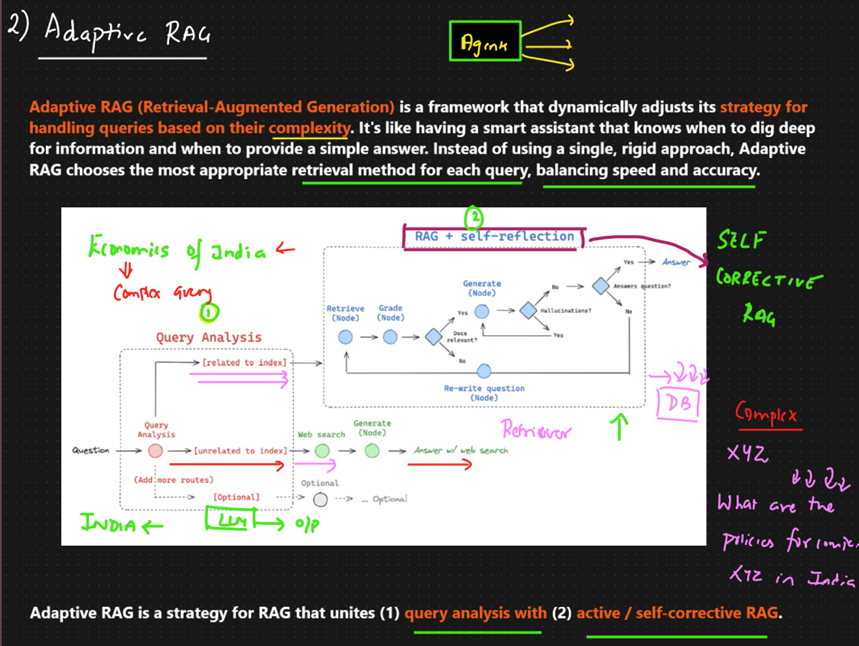

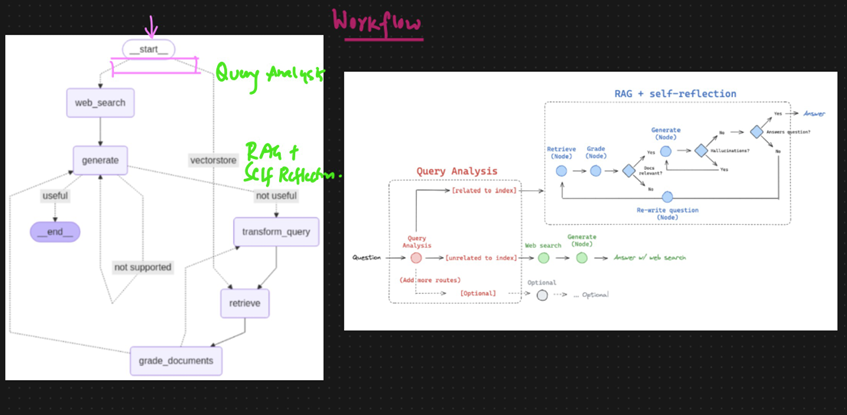
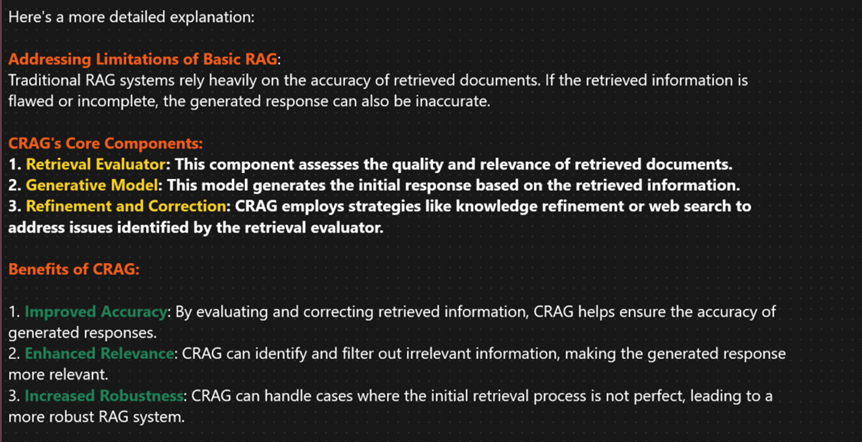
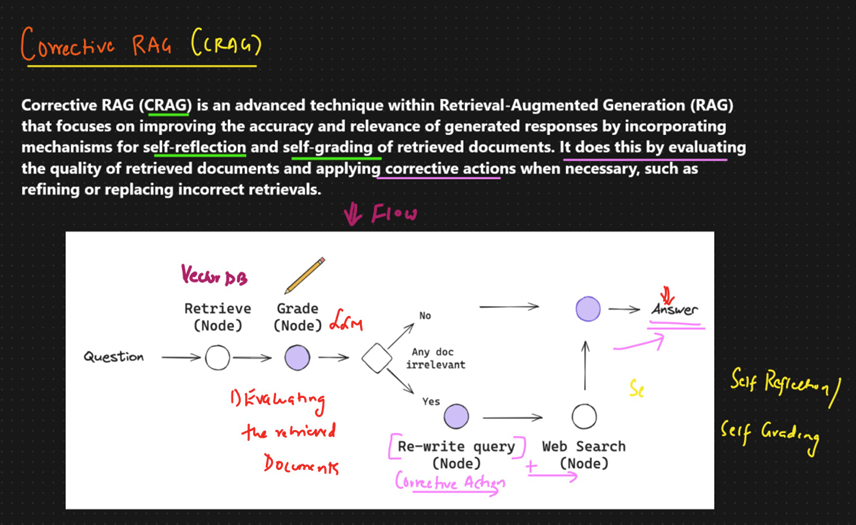

In [1]:
import os
from dotenv import load_dotenv
load_dotenv() ## aloading all the environment variable

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [2]:
### Build Index

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

### from langchain_cohere import CohereEmbeddings

# Set embeddings
embd = OpenAIEmbeddings()

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)

retriever=vectorstore.as_retriever()

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
## Router 
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field

# Data Model

class RouteQuery(BaseModel):
    """ Route a user query to the most relevant datasource """
    datasource : Literal["vectorstore","web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorestore",
    )

## Initialize LLM model 
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

system =""" You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks. 
Use the vectorstore for question on these topics. Otherwise, use web-search """

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system" , system),
        ("human" , "{question}")
    ]
)

question_router = route_prompt | structured_llm_router

print(
    question_router.invoke(
        {"question": "Who won the Cricket world cup 2023 "}
    )
)


datasource='web_search'


In [6]:
print(question_router.invoke({"question": "What are the types of agent memory?"}))

datasource='vectorstore'


In [7]:
### Retrieval Grader

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field

# Data Model
class GradeDocuments(BaseModel):
    """ Binary score for relevance check on retrived documents """
    binary_score :str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

## Initialize LLM model 
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)
llm 

structured_llm_grade = llm.with_structured_output(GradeDocuments)

#Prompt 
system = """ You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
 
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system" , system),
        ("human", "Retrieved document: \n\n {document} \n\n User Question: {question}")
    ]
)

## Chain the prompt with the LLM
retrieval_grader = grade_prompt | structured_llm_grade
question ="Agent Memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content

print(retrieval_grader.invoke({"question" : question, "document":doc_txt}))

binary_score='yes'


In [8]:
### Generate

# from langchainhub import pull
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser

client = Client()
# Pull public prompt from LangChain Hub (needs author handle)
prompt = client.pull_prompt("rlm/rag-prompt")

llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

# Post Processing

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs) 

#chain
rag_chain = prompt | llm| StrOutputParser()

# Run 
generation = rag_chain.invoke({"context" : docs, "question":question})
print(generation)
 

Agent memory in LLM-powered autonomous agents consists of short-term and long-term memory components. Short-term memory involves in-context learning, utilizing the model's finite context window. Long-term memory allows the agent to retain and recall information over extended periods by leveraging an external vector store and fast retrieval mechanisms.


In [9]:
### Hallucination Grader


# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucinations(binary_score='yes')

In [10]:
### Answer Grader


# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

In [11]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'What is the role of memory in artificial intelligence agents?'

In [12]:
### Search

from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(k=3)

In [13]:
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation 
        documents: list of documents
    """

    question: str
    generation: str 
    documents: List[str]

In [22]:
from langchain_core.documents import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]

    # Tavily response can be either a dict with a "results" list or a direct list.
    raw = web_search_tool.invoke({"query": question})
    results = raw.get("results", []) if isinstance(raw, dict) else raw

    web_docs = []
    for item in results or []:
        if isinstance(item, dict):
            content = item.get("content") or item.get("snippet") or item.get("title")
            if content:
                web_docs.append(Document(page_content=content, metadata=item))
        elif isinstance(item, str):
            web_docs.append(Document(page_content=item))

    # Keep the graph contract consistent: documents should be a list[Document].
    return {"documents": web_docs, "question": question}


### Edges ###


def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question})
    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"


def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [23]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
app = workflow.compile()

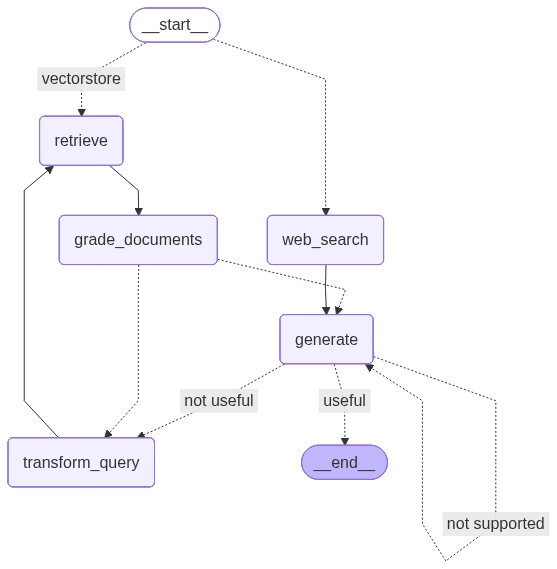

In [24]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [20]:
app.invoke({"question":"What are the types of agent memory?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What are the types of agent memory?',
 'generation': 'The types of agent memory are short-term memory and long-term memory. Short-term memory involves in-context learning within the finite context window of a Transformer model. Long-term memory allows the agent to retain and recall information over extended periods, often using an external vector store for fast retrieval.',
 'documents': [Document(id='d9fd9754-48c1-4a69-ac4d-b0c450156052', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autono

In [25]:
app.invoke({"question":"What is machine learning"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is machine learning',
 'generation': 'Machine learning is a subset of artificial intelligence that focuses on developing algorithms that improve automatically through experience and data. It involves creating models capable of performing tasks such as categorizing images, analyzing data, or predicting outcomes without explicit instructions. Essentially, machine learning enables algorithms to uncover hidden patterns within datasets and make accurate inferences about new data.',
 'documents': [Document(metadata={'url': 'https://www.datacamp.com/blog/what-is-machine-learning', 'title': 'What is Machine Learning? Definition, Types, Tools & More', 'content': '# What is Machine Learning? ## What is Machine Learning? Machine Learning, often abbreviated as ML, is a subset of artificial intelligence (AI) that focuses on the development of computer algorithms that improve automatically through experience and by the use of data. **Machine learning** is a subset of AI, which use